In [1]:
!pip install bitsandbytes -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.5 MB/s eta 0:00:00


In [2]:
from huggingface_hub import hf_hub_download
from datasets import Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import math
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, get_scheduler
from peft import LoraConfig, get_peft_model
from transformers import Trainer, TrainingArguments,TrainerCallback
from torch.amp import autocast, GradScaler
import bitsandbytes as bnb
from tqdm.auto import tqdm

In [3]:
train_path = hf_hub_download(
    repo_id="Psychotherapy-LLM/PsychoCounsel-Preference",
    repo_type="dataset",
    filename="data/train-00000-of-00001.parquet"
)

test_path = hf_hub_download(
    repo_id="Psychotherapy-LLM/PsychoCounsel-Preference",
    repo_type="dataset",
    filename="data/test-00000-of-00001.parquet"
)

print(train_path)
print(test_path)

data/train-00000-of-00001.parquet:   0%|          | 0.00/37.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/3.81M [00:00<?, ?B/s]

/root/.cache/huggingface/hub/datasets--Psychotherapy-LLM--PsychoCounsel-Preference/snapshots/e6b885f3f99f93dd21b8c00d171c3fe9740bb615/data/train-00000-of-00001.parquet
/root/.cache/huggingface/hub/datasets--Psychotherapy-LLM--PsychoCounsel-Preference/snapshots/e6b885f3f99f93dd21b8c00d171c3fe9740bb615/data/test-00000-of-00001.parquet


In [4]:
train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

In [5]:
train.head(5)

,ID,prefID,question,chosen,rejected,chosen_model,rejected_model,chosen_empathy_rating,chosen_relevance_rating,chosen_clarity_rating,...,chosen_exploration_rating,chosen_autonomy_rating,chosen_staging_rating,rejected_empathy_rating,rejected_relevance_rating,rejected_clarity_rating,rejected_safety_rating,rejected_exploration_rating,rejected_autonomy_rating,rejected_staging_rating
0,therapistQA-4356,0,Please help. I really don’t like my boyfriend...,Thank you for sharing your feelings so openly....,It sounds like you have developed some mixed f...,GPT-4o-mini,MiniCPM3-4B,5,5,4,...,4,4,4,3,4,3,4,5,2,3
1,mentalChat16k-1726,1,I've always felt like I've failed as a mother ...,I hear you sharing your deep concerns and fee...,It sounds like you're experiencing a lot of gu...,Phi-3.5-mini-instruct,MiniCPM3-4B,5,5,2,...,4,5,4,4,3,4,4,2,2,3
2,mentalChat16k-1726,2,I've always felt like I've failed as a mother ...,Thank you for sharing that with me. It sounds ...,It sounds like you're experiencing a lot of gu...,Qwen2.5-7B-Instruct,MiniCPM3-4B,4,4,3,...,5,4,4,4,3,4,4,2,2,3
3,psycho8k-3135,3,I've been struggling with maintaining good gra...,I'm really sorry to hear that you're feeling c...,I'm sorry to hear that you've been struggling ...,Ministral-8B-Instruct-2410,deepseek-llm-67b-chat,4,5,2,...,5,5,4,3,3,3,4,3,4,3
4,psycho8k-5118,4,I'm struggling with my son's transition from s...,I can sense the concern and worry in your voic...,It sounds like your son is experiencing a sign...,Llama-3.2-3B-Instruct,MiniCPM3-4B,5,5,3,...,4,5,4,3,3,4,5,2,4,3


In [6]:
train_hf = Dataset.from_pandas(train[['question', 'chosen']])
test_hf = Dataset.from_pandas(test[['question', 'chosen']])

In [7]:
def format_dataset(example):
    return {
        "query": str(example['question']).lower().strip(),
        "ans": example['chosen']
    }
    
column_names = train_hf.column_names 

trainset = train_hf.map(
    format_dataset, 
    remove_columns=column_names
)
testset = test_hf.map(
    format_dataset, 
    remove_columns=column_names
)

Map:   0%|          | 0/34329 [00:00<?, ? examples/s]

Map:   0%|          | 0/2324 [00:00<?, ? examples/s]

In [8]:
trainset[0]

{'query': 'please help. i really don’t like my boyfriends daughter. i don’t really know why. we’ve been together for two years and his daughter is two. she was four weeks old when we got together but i had been aeeimg my boyfriend before she was born. there was a period of time that i was not aware of her existance. he didn’t have a lot to do with her after she was born (for the first year) but i encouraged him strongly to see her more and spend time with her. he did this and i thought it was great. i didn’t mind her being around at all.',
 'ans': "Thank you for sharing your feelings so openly. It sounds like you’re experiencing some complex emotions regarding your boyfriend’s daughter, and it’s completely understandable to have mixed feelings in a situation like this. \n\nYou mentioned that you encouraged your boyfriend to be more involved with her after she was born, which shows that you care about their relationship. However, it seems like there’s been a shift in how you feel since 

In [9]:
model_id = 'HuggingFaceTB/SmolLM2-135M-Instruct'

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="auto" 
)
tokenizer = AutoTokenizer.from_pretrained(model_id)

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

In [10]:
config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules='all-linear',
    task_type="CAUSAL_LM",
    use_dora=True
)

model = get_peft_model(base_model,config).to("cuda")

for param in model.parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float32)
        
model.print_trainable_parameters()

trainable params: 5,040,000 || all params: 139,555,008 || trainable%: 3.6115


In [11]:
tokenizer.padding_side = "right"
tokenizer.special_tokens_map

{'bos_token': '<|im_start|>',
 'eos_token': '<|im_end|>',
 'unk_token': '<|endoftext|>',
 'pad_token': '<|im_end|>'}

Calculating token lengths...


  0%|          | 0/34329 [00:00<?, ?it/s]


--- Token Length Statistics ---
Mean Length: 421.5
Max Length:  1953
95th Pct:    741.0
99th Pct:    907.0


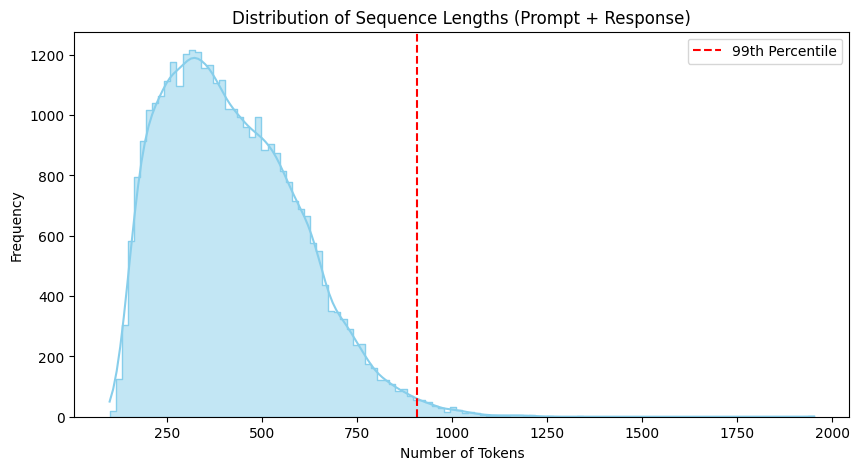

In [12]:
def get_token_lengths(df, tokenizer):
    lengths = []
    print("Calculating token lengths...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        q = str(row['question']) if pd.notnull(row['question']) else ""
        a = str(row['chosen']) if pd.notnull(row['chosen']) else ""
        
        messages = [
                {
                    "role": "system",
                    "content": "You are a compassionate AI mental health assistant. Respond with empathy, provide supportive guidance, and encourage healthy coping strategies without giving medical diagnoses."
                },
                {"role": "user", "content": q},
                {"role": "assistant", "content": a}
            ]
        
        tokens = tokenizer.apply_chat_template(
            messages, 
            tokenize=True, 
            add_generation_prompt=False,
            return_tensors=None 
        )
        
        lengths.append(len(tokens.input_ids))
    return lengths

train_lengths = get_token_lengths(train, tokenizer)

print(f"\n--- Token Length Statistics ---")
print(f"Mean Length: {np.mean(train_lengths):.1f}")
print(f"Max Length:  {max(train_lengths)}")
print(f"95th Pct:    {np.percentile(train_lengths, 95)}")
print(f"99th Pct:    {np.percentile(train_lengths, 99)}")

plt.figure(figsize=(10, 5))
sns.histplot(train_lengths, color="skyblue", kde=True, element="step")
plt.title("Distribution of Sequence Lengths (Prompt + Response)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.axvline(np.percentile(train_lengths, 99), color='red', linestyle='--', label='99th Percentile')
plt.legend()

In [13]:
class SFTDataCollator:
    def __init__(self, tokenizer, max_length=1024):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, batch):
        texts = []
        prompt_lengths = []
        
        for item in batch:
            messages = [
                {"role": "system", "content": "You are a compassionate AI mental health assistant. Respond with empathy, provide supportive guidance, and encourage healthy coping strategies without giving medical diagnoses."},
                {"role": "user", "content": item["query"]},
                {"role": "assistant", "content": item["ans"]}
            ]
            
            text = self.tokenizer.apply_chat_template(messages, tokenize=False)
            texts.append(text)
            
            prompt_messages = messages[:-1] 
            prompt_text = self.tokenizer.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
            prompt_tokens = self.tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
            prompt_lengths.append(len(prompt_tokens))

        tokenized = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = tokenized["input_ids"]
        attention_mask = tokenized["attention_mask"]
        labels = input_ids.clone()
        
        for i, length in enumerate(prompt_lengths):
            trunc_length = min(length, self.max_length)
            labels[i, :trunc_length] = -100

        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

collator = SFTDataCollator(tokenizer)

trainloader = DataLoader(
    trainset, 
    batch_size=4, 
    shuffle=True, 
    collate_fn=collator 
)

testloader = DataLoader(
    testset, 
    batch_size=4, 
    shuffle=False, 
    collate_fn=collator
)

In [14]:
d = next(iter(trainloader))
print('inp ids:',d['input_ids'].shape)
print('labels:',d['labels'].shape)

inp ids: torch.Size([4, 460])
labels: torch.Size([4, 460])


In [15]:
print(tokenizer.decode(d['input_ids'][0]))

<|im_start|>system
You are a compassionate AI mental health assistant. Respond with empathy, provide supportive guidance, and encourage healthy coping strategies without giving medical diagnoses.<|im_end|>
<|im_start|>user
i just feel like i have no peace and have to hold back all the time. it's like i'm always in a state of constant irritation, even when little things like someone cutting me off while driving trigger me. i don't feel like i can just relax.<|im_end|>
<|im_start|>assistant
It sounds like you're experiencing a lot of inner turmoil and a heightened sense of stress or anxiety. This constant state of irritation and the feeling of having to hold back can be exhausting and impact your overall well-being. 

It's important to understand that everyone has a different tolerance level for stress and irritation, and what might be a minor inconvenience for one person could be a trigger for another. It's okay to acknowledge and validate your feelings; recognizing that you're in a con

In [16]:
labels = d['labels'][0]
labels[labels==-100] = tokenizer.eos_token_id
print(tokenizer.decode(labels))

<|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|>It sounds like you're experiencing a lot of inner 

In [17]:
num_epochs = 2
batch_size = 2
grad_accum_steps = 4
effective_batch_size = batch_size * grad_accum_steps
total_train_steps = (len(trainset) // effective_batch_size) * num_epochs
eval_and_save_steps = max(1, total_train_steps // 2)
warmup_steps = int(0.05 * total_train_steps)

In [18]:
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        print(f"Memory cleared. Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")

clear_memory()

Memory cleared. Allocated: 283.98 MB


In [19]:
model.train()
model.config.use_cache = False

training_args = TrainingArguments(
    output_dir="./outputs",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=grad_accum_steps,
    num_train_epochs=num_epochs,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps,  
    eval_strategy="steps",            
    save_strategy="steps",            
    eval_steps=eval_and_save_steps,   
    save_steps=eval_and_save_steps,  
    load_best_model_at_end=True,     
    metric_for_best_model="loss",     
    save_total_limit=2,                
    logging_steps=eval_and_save_steps,
    fp16=True,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    weight_decay=0.05,
    max_grad_norm=1.0,
    seed=3407,
    report_to="none",
    remove_unused_columns=False,
)

In [20]:
class PrintLossCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return

        step = state.global_step
        train_loss = logs.get("loss")
        eval_loss  = logs.get("eval_loss")

        if train_loss is not None:
            train_ppl = math.exp(train_loss) if train_loss < 100 else float("inf")
            print(f"Step {step} | Train Loss: {train_loss:.4f} | Train PPL: {train_ppl:.2f}")

        if eval_loss is not None:
            eval_ppl = math.exp(eval_loss) if eval_loss < 100 else float("inf")
            print(f"Step {step} | Eval  Loss: {eval_loss:.4f} | Eval  PPL: {eval_ppl:.2f}")

In [21]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=trainset,
    eval_dataset=testset,
    data_collator=collator,
    callbacks=[PrintLossCallback()]
)

In [22]:
trainer.train()

Step,Training Loss,Validation Loss
4291,1.306214,1.256000
8582,1.224024,1.238547


Step 4291 | Train Loss: 1.3062 | Train PPL: 3.69
Step 4291 | Eval  Loss: 1.2560 | Eval  PPL: 3.51
Step 8582 | Train Loss: 1.2240 | Train PPL: 3.40
Step 8582 | Eval  Loss: 1.2385 | Eval  PPL: 3.45


TrainOutput(global_step=8584, training_loss=1.265047801146414, metrics={'train_runtime': 28818.6206, 'train_samples_per_second': 2.382, 'train_steps_per_second': 0.298, 'total_flos': 2.388366942338189e+16, 'train_loss': 1.265047801146414, 'epoch': 2.0})

In [23]:
trainer.save_model("./best_lora_adapters")

In [24]:
clear_memory()

Memory cleared. Allocated: 304.09 MB


In [25]:
merged_model = model.merge_and_unload()

In [26]:
output_merged_dir = "./final_merged_model"
merged_model.save_pretrained(output_merged_dir, safe_serialization=True)
tokenizer.save_pretrained(output_merged_dir)

print(f"Success! Merged model is saved in: {output_merged_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Success! Merged model is saved in: ./final_merged_model


In [27]:
model_path = "./final_merged_model"
print(f"Loading merged model from {model_path} for inference...")

inf_tokenizer = AutoTokenizer.from_pretrained(model_path)
inf_model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map="auto"
)

def generate_counseling_response(user_query, max_new_tokens=512):
    system_prompt = "You are a compassionate AI mental health assistant. Respond with empathy, provide supportive guidance, and encourage healthy coping strategies without giving medical diagnoses."
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_query}
    ]
    
    prompt = inf_tokenizer.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True 
    )
    
    inputs = inf_tokenizer(prompt, return_tensors="pt").to(inf_model.device)
    
    with torch.no_grad():
        outputs = inf_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=1.0,       
            top_p=0.9,
            repetition_penalty=1.1, 
            do_sample=True,
            pad_token_id=inf_tokenizer.eos_token_id
        )
    
    input_length = inputs.input_ids.shape[1]
    generated_tokens = outputs[0][input_length:]
    response = inf_tokenizer.decode(generated_tokens, skip_special_tokens=True)
    
    return response.strip()

Loading merged model from ./final_merged_model for inference...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

In [28]:
test_query = "I've been feeling incredibly overwhelmed with work lately and I can't seem to turn my brain off at night. I just lie there worrying."

print("-" * 50)
print(f"User: {test_query}\n")
print(f"Assistant:\n{generate_counseling_response(test_query)}")
print("-" * 50)

--------------------------------------------------
User: I've been feeling incredibly overwhelmed with work lately and I can't seem to turn my brain off at night. I just lie there worrying.

Assistant:
It sounds like you're feeling really drained after working so much and it's impacting your sleep patterns. It’s completely understandable that this is affecting how you feel right now. The physical act of lying in bed for hours can sometimes trigger those feelings. Could you share more about what specifically is making you feel overwhelmed when you go to bed? Sometimes understanding these underlying feelings helps us navigate through them more effectively.
--------------------------------------------------
